# Alpha Earth Embeddings Demo

AlphaEarth Foundations (AEF) gives a 64-number vector for every 10 m pixel, distilled from a whole year of many sensors (optical and radar).

In [1]:
import geopandas as gpd
import pandas as pd
import ee
import os
from os.path import join, expanduser, exists
from gee_zonal.gee_helpers import gpd_to_gee
import leafmap.foliumap as leafmap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [2]:
ee.Initialize()

Our areas of interest are Malawi survey clusters from the Demographic and Health Surveys (DHS) program.

In [3]:
gdf = gpd.read_file('dhs_pairs_mwi.geojson')
gdf_buff = gdf.copy()
buffer_distance = 2300
gdf_buff.loc[:, "geometry"] = gdf_buff.loc[:, "geometry"].buffer(buffer_distance)
gdf_buff = gdf_buff.to_crs("EPSG:4326")

<Axes: >

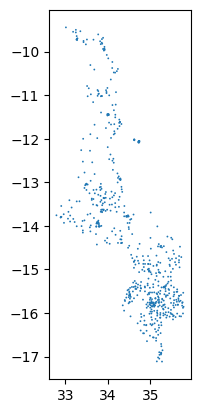

In [4]:
gdf_buff.plot()

In [5]:
aoi = gdf_buff.iloc[[0]]
aoi_ee = gpd_to_gee(aoi)

In [6]:
alphaearth_2024 = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL").filterDate('2024-01-01', '2025-01-01')
image_last = alphaearth_2024 \
    .filterBounds(aoi_ee) \
    .mosaic() \
    .clip(aoi_ee.bounds())

In [7]:
image_last

### RGB visualization of three first dimensions of AlphaEarth embeddings

In [9]:
# --- AlphaEarth annual embeddings, 2024 ---
emb_2024 = (
    ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
    .filterDate("2024-01-01", "2025-01-01")
    .filterBounds(aoi_ee)
    .mosaic()
    .clip(aoi_ee.geometry().bounds())
)

# 3 of the 64 embedding dimensions shown as RGB (arbitrary choice, for display only)
vis = {"bands": ["A01", "A16", "A09"], "min": -0.3, "max": 0.3}

def ee_tile_url(image, vis_params):
    return image.getMapId(vis_params)["tile_fetcher"].url_format

# --- Map ---
m = leafmap.Map()
m.add_basemap("SATELLITE")
m.add_tile_layer(
    url=ee_tile_url(emb_2024, vis),
    name="AlphaEarth 2024 (A01/A16/A09)",
    attribution="Google Earth Engine",
)
m.add_gdf(aoi, layer_name="AOI buffer",
          style={"color": "yellow", "fillOpacity": 0})
m

## t-SNE Plot of Embeddings by Land Cover Class

3000 pixels sampled
landcover
Cropland      2105
Shrubland      552
Tree cover     206
Grassland      121
Built-up        16
Name: count, dtype: int64


  File "c:\WBG\Anaconda3\envs\geezonal\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\WBG\Anaconda3\envs\geezonal\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\WBG\Anaconda3\envs\geezonal\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\WBG\Anaconda3\envs\geezonal\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


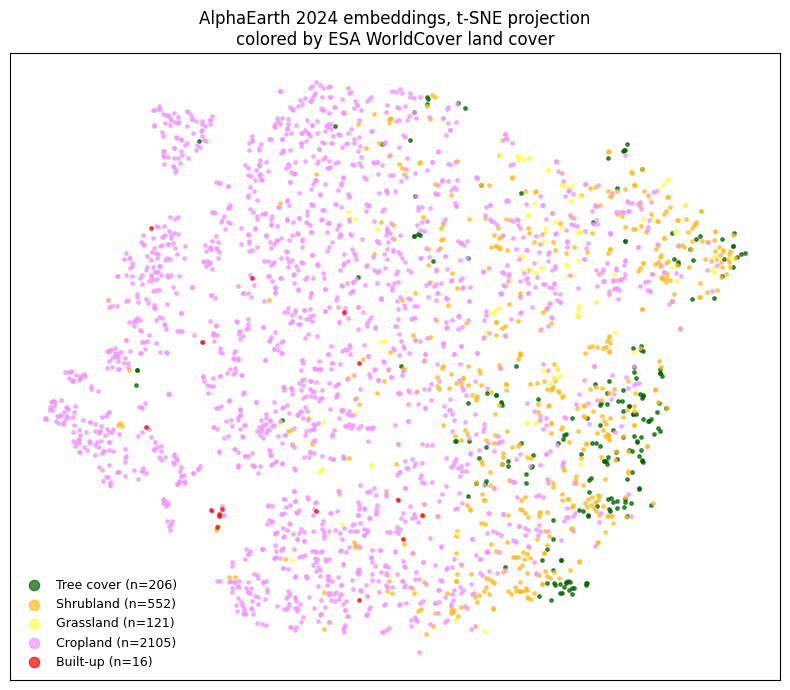

In [10]:
# --- Land cover labels for coloring (ESA WorldCover 10 m, 2021) ---
worldcover = (
    ee.ImageCollection("ESA/WorldCover/v200")
    .first()
    .select("Map")
    .rename("landcover")
)

wc_classes = {
    10: ("Tree cover", "#006400"),
    20: ("Shrubland", "#ffbb22"),
    30: ("Grassland", "#ffff4c"),
    40: ("Cropland", "#f096ff"),
    50: ("Built-up", "#fa0000"),
    60: ("Bare / sparse", "#b4b4b4"),
    80: ("Water", "#0064c8"),
    90: ("Herbaceous wetland", "#0096a0"),
}

# --- Sample pixels: 64 embedding bands + land cover label ---
samples = emb_2024.addBands(worldcover).sample(
    region=aoi_ee.geometry(),
    scale=10,
    numPixels=3000,   # approximate; masked pixels are dropped
    seed=42,
    geometries=False,
)

df = ee.data.computeFeatures({
    "expression": samples,
    "fileFormat": "PANDAS_DATAFRAME",
})

band_cols = [f"A{i:02d}" for i in range(64)]
df = df.dropna(subset=band_cols + ["landcover"])
print(f"{len(df)} pixels sampled")
print(df["landcover"].map(lambda c: wc_classes.get(c, ("Other",))[0]).value_counts())

# --- t-SNE to 2D ---
X = df[band_cols].to_numpy()
xy = TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(X)
df["tsne_1"], df["tsne_2"] = xy[:, 0], xy[:, 1]

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 7))
for code, group in df.groupby("landcover"):
    label, color = wc_classes.get(int(code), (f"Class {int(code)}", "#444444"))
    ax.scatter(group["tsne_1"], group["tsne_2"], s=6, alpha=0.7,
               color=color, label=f"{label} (n={len(group)})")

ax.set_title("AlphaEarth 2024 embeddings, t-SNE projection\ncolored by ESA WorldCover land cover")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(markerscale=3, fontsize=9, loc="best", frameon=False)
plt.tight_layout()
plt.show()

In [11]:
df

,geo,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,A57,A58,A59,A60,A61,A62,A63,landcover,tsne_1,tsne_2
0,None,0.119093,0.130165,-0.141730,-0.062991,0.088827,0.098424,0.055363,0.160000,-0.012057,...,-0.059116,-0.141730,0.032541,0.130165,-0.051734,0.038447,-0.251965,20,31.964533,-34.097252
1,None,0.186082,0.108512,-0.124567,-0.088827,0.066990,0.113741,0.119093,0.055363,-0.004983,...,-0.003014,-0.186082,0.079723,0.160000,-0.038447,-0.000984,-0.236463,40,10.942188,26.731041
2,None,0.130165,0.172795,-0.084214,-0.024606,0.062991,0.153787,0.119093,0.108512,-0.035433,...,-0.008858,-0.153787,0.032541,0.113741,-0.032541,0.084214,-0.244152,40,-14.329392,-50.503750
3,None,0.141730,0.160000,-0.062991,0.027128,0.084214,0.113741,0.135886,0.051734,-0.038447,...,-0.012057,-0.153787,-0.008858,0.071111,-0.015748,0.093564,-0.214133,40,-28.804352,-38.108067
4,None,0.192910,0.119093,-0.108512,-0.124567,0.051734,0.093564,0.160000,0.027128,-0.032541,...,0.006151,-0.113741,0.071111,0.166336,-0.084214,-0.093564,-0.214133,40,-8.147647,52.342213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,None,0.153787,0.135886,-0.141730,-0.079723,0.041584,0.113741,0.119093,0.113741,-0.051734,...,0.015748,-0.130165,0.071111,0.153787,-0.055363,0.019931,-0.284444,40,7.663959,27.034645
2996,None,0.124567,0.130165,-0.113741,-0.044844,0.055363,0.192910,0.084214,0.160000,-0.079723,...,0.008858,-0.051734,0.044844,0.124567,-0.079723,0.071111,-0.301423,40,2.758120,-30.587055
2997,None,0.179377,0.166336,-0.135886,-0.062991,0.130165,0.130165,0.055363,0.160000,-0.015748,...,-0.048228,-0.103406,-0.008858,0.119093,-0.075356,-0.010396,-0.259900,20,55.309959,26.950802
2998,None,0.119093,0.186082,-0.051734,-0.029773,0.055363,0.141730,0.108512,0.071111,-0.015748,...,-0.013841,-0.172795,0.038447,0.130165,-0.013841,0.055363,-0.214133,40,-45.560223,-33.102081
